In [1]:
import os
import sys
import warnings

import IPython
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

warnings.filterwarnings("ignore")


In [2]:
_base = os.getcwd()
_project_root = (
    os.path.dirname(_base) if os.path.basename(_base).lower() == "training" else _base
)
ALL_EMOTIONS_CSV = os.path.normpath(
    os.path.join(_project_root, "dataset", "all_emotions.csv")
)

print("CSV path:", ALL_EMOTIONS_CSV)
print("Exists:", os.path.isfile(ALL_EMOTIONS_CSV))

RANDOM_STATE = 42
TEST_SIZE = 0.2
OPTUNA_TRIALS = 60
CV_SPLITS = 5


CSV path: d:\Code\Python\Emotion_detecting\dataset\all_emotions.csv
Exists: True


In [3]:
df = pd.read_csv(ALL_EMOTIONS_CSV)
print("Shape:", df.shape)

# Target column in CSV is lowercase 'label' (RF.md names it Label)
TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

print("\n--- Null counts (top 15) ---")
nulls = df.isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0].head(15) if nulls.max() > 0 else "No nulls")

print("\n--- Duplicated rows ---", df.duplicated().sum())

print("\n--- Label distribution ---")
print(df[TARGET_COL].astype(str).value_counts(dropna=False))


Shape: (54485, 49)

--- Null counts (top 15) ---
No nulls

--- Duplicated rows --- 0

--- Label distribution ---
label
fear       9315
anger      9315
happy      9315
disgust    9315
sad        9310
neutral    7915
Name: count, dtype: int64


In [4]:
FEATURE_COLS = ["F0_mean", "F0_std", "F0_range", "Energy_ mean", "Energy_ std", "ZCR_mean", "ZCR_std", "Spectral_centroid_mean", "Spectral_centroid_std", "Spectral_flux_mean", "MFCC_C0_mean", "MFCC_C1_mean", "MFCC_C2_mean", "MFCC_C3_mean", "MFCC_C4_mean", "MFCC_C5_mean", "MFCC_C6_mean", "MFCC_C7_mean", "MFCC_C8_mean", "MFCC_C9_mean", "MFCC_C10_mean", "MFCC_C11_mean", "MFCC_C12_mean", "MFCC_C0_std", "MFCC_C1_std", "MFCC_C2_std", "MFCC_C3_std", "MFCC_C4_std", "MFCC_C5_std", "MFCC_C6_std", "MFCC_C7_std", "MFCC_C8_std", "MFCC_C9_std", "MFCC_C10_std", "MFCC_C11_std", "MFCC_C12_std", "Delta_MFCC_C0_mean", "Delta_MFCC_C1_mean", "Delta_MFCC_C2_mean", "Delta_MFCC_C3_mean", "Delta_MFCC_C4_mean", "Delta_MFCC_C5_mean", "Delta_MFCC_C0_std", "Delta_MFCC_C1_std", "Delta_MFCC_C2_std", "Delta_MFCC_C3_std", "Delta_MFCC_C4_std", "Delta_MFCC_C5_std"]

TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

missing_feat = [c for c in FEATURE_COLS if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing feature columns: {missing_feat[:5]} ...")

# Drop rows with invalid target
_df = df.dropna(subset=[TARGET_COL]).copy()
_df = _df[_df[TARGET_COL].astype(str).str.strip().str.lower() != "nan"]

X = _df[FEATURE_COLS].copy()
y_label = _df[TARGET_COL].astype(str).str.strip()

print("X shape:", X.shape)
print("y unique:", sorted(y_label.unique()))


X shape: (54485, 48)
y unique: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']


In [5]:
# NaN / Inf in features -> median imputation (per column), no StandardScaler (RF.md)
X_proc = X.copy()
for c in FEATURE_COLS:
    s = pd.to_numeric(X_proc[c], errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    med = s.median()
    if pd.isna(med):
        med = 0.0
    X_proc[c] = s.fillna(med)

rem_nan = X_proc.isna().sum().sum()
rem_inf = np.isinf(X_proc.select_dtypes(include=[np.number]).values).sum()
print("Remaining NaN cells:", int(rem_nan), "| inf:", int(rem_inf))
X = X_proc


Remaining NaN cells: 0 | inf: 0


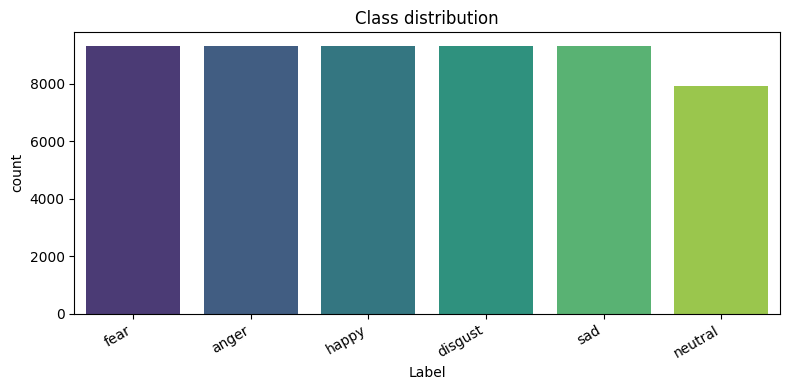

In [6]:
plt.figure(figsize=(8, 4))
order = y_label.value_counts().index.tolist()
sns.countplot(data=pd.DataFrame({"Label": y_label}), x="Label", order=order, palette="viridis")
plt.title("Class distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


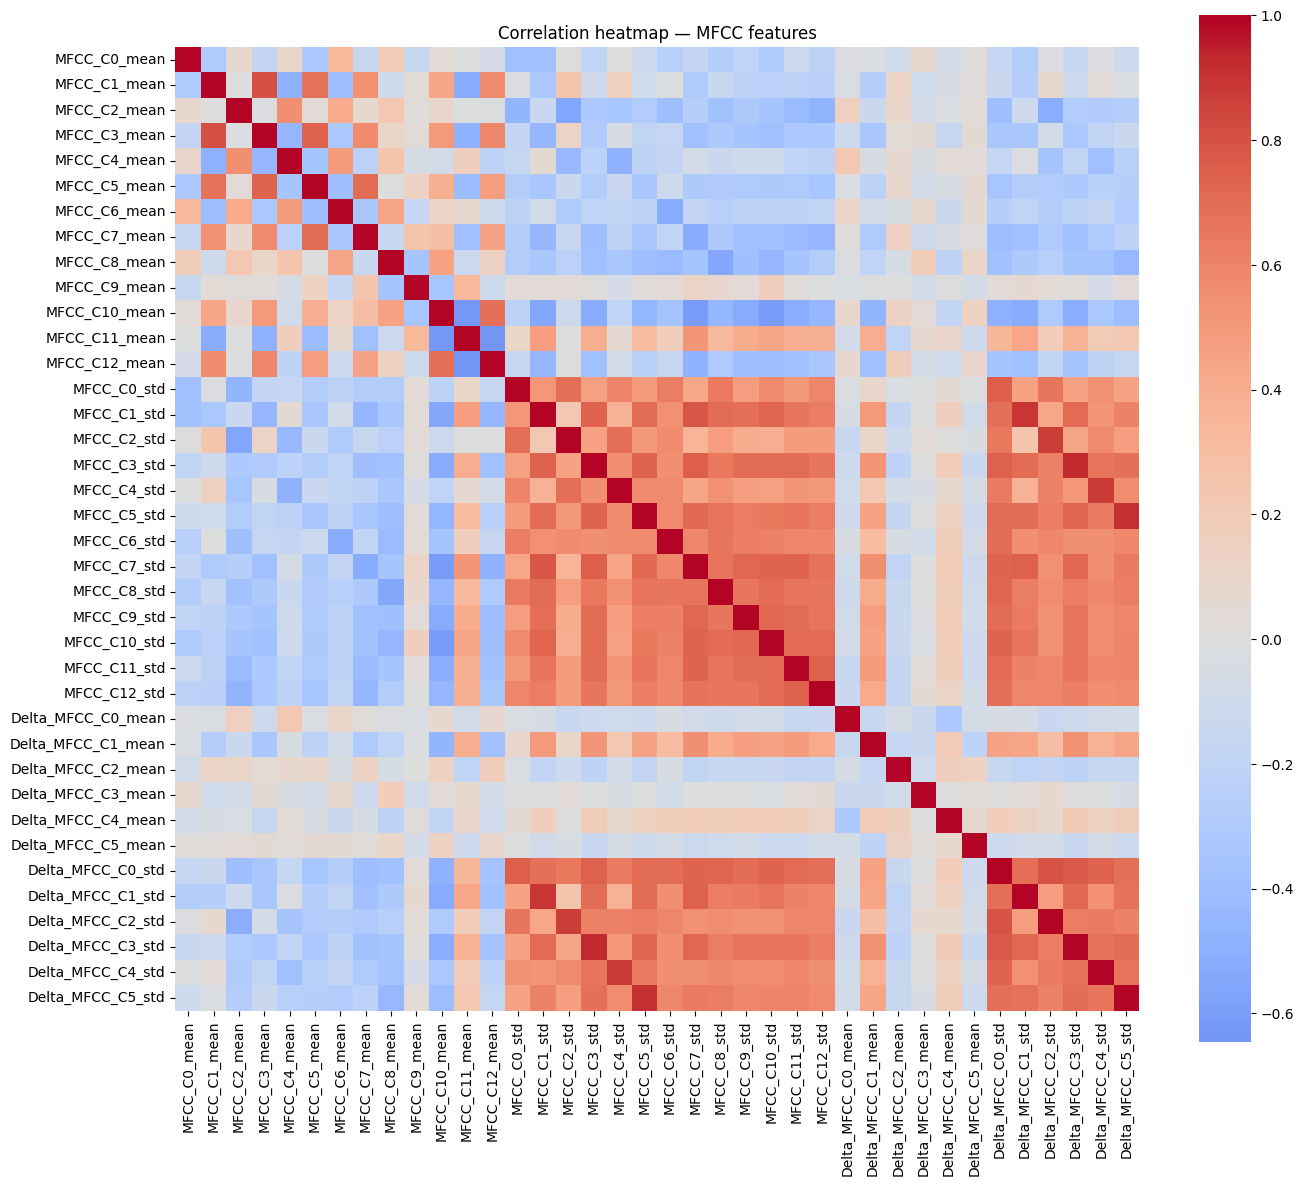

In [7]:
mfcc_cols = [c for c in FEATURE_COLS if "MFCC" in c]
cm = X[mfcc_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap — MFCC features")
plt.tight_layout()
plt.show()


In [8]:
le = LabelEncoder()
y = le.fit_transform(y_label)

print("label_id -> label_name:")
for i, name in enumerate(le.classes_):
    print(f"  {i} -> {name}")

X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
print("Train:", X_train.shape, "Test:", X_test.shape)


label_id -> label_name:
  0 -> anger
  1 -> disgust
  2 -> fear
  3 -> happy
  4 -> neutral
  5 -> sad
Train: (43588, 48) Test: (10897, 48)


In [9]:
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def objective(trial: optuna.Trial) -> float:
    max_depth_choice = trial.suggest_categorical(
        "max_depth", [None] + list(range(15, 36))
    )
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 250),
        "max_depth": max_depth_choice,
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    clf = RandomForestClassifier(**params)
    scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1,
    )
    return float(scores.mean())


In [ ]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print("Best value (CV mean F1 weighted):", study.best_value)
print("Best params:", study.best_params)
best_params = study.best_params.copy()

In [ ]:
df_hist = study.trials_dataframe()
df_hist = df_hist.sort_values("number")

plt.figure(figsize=(10, 4))
plt.plot(df_hist["number"], df_hist["value"], marker="o", ms=3, alpha=0.7)
plt.xlabel("Trial")
plt.ylabel("CV mean F1 (weighted)")
plt.title("Optuna optimization history")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_hist["number"], df_hist["value"].cummax(), color="tab:red", lw=2)
plt.xlabel("Trial")
plt.ylabel("Best-so-far CV F1 (weighted)")
plt.title("Optuna convergence (best-so-far)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
final_params = {
    "n_estimators": best_params["n_estimators"],
    "max_depth": best_params["max_depth"],
    "max_features": best_params["max_features"],
    "min_samples_split": best_params["min_samples_split"],
    "min_samples_leaf": best_params["min_samples_leaf"],
    "bootstrap": best_params["bootstrap"],
    "class_weight": best_params["class_weight"],
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
# OOB only valid when bootstrap=True (RF.md)
final_params["oob_score"] = bool(best_params["bootstrap"])

rf_final = RandomForestClassifier(**final_params)
rf_final.fit(X_train, y_train)
print("Fitted. oob_score:", getattr(rf_final, "oob_score_", None))


In [ ]:
if not best_params["bootstrap"]:
    print("bootstrap=False -> OOB score not defined; skip OOB error curve.")
else:
    n_grid = np.linspace(10, int(best_params["n_estimators"]), 8, dtype=int)
    n_grid = np.unique(np.clip(n_grid, 10, None))
    oob_scores = []
    for n_est in n_grid:
        m = RandomForestClassifier(
            n_estimators=int(n_est),
            max_depth=best_params["max_depth"],
            max_features=best_params["max_features"],
            min_samples_split=best_params["min_samples_split"],
            min_samples_leaf=best_params["min_samples_leaf"],
            bootstrap=True,
            oob_score=True,
            class_weight=best_params["class_weight"],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        m.fit(X_train, y_train)
        oob_scores.append(m.oob_score_)

    oob_err = 1.0 - np.array(oob_scores)
    plt.figure(figsize=(8, 4))
    plt.plot(n_grid, oob_err, marker="o")
    plt.xlabel("n_estimators")
    plt.ylabel("OOB error (1 - OOB score)")
    plt.title("OOB error vs n_estimators")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
_lc_params = {k: v for k, v in final_params.items() if k != "oob_score"}
train_sizes, train_scores, valid_scores = learning_curve(
    RandomForestClassifier(**_lc_params),
    X_train,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="f1_weighted",
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, label="Train F1 (weighted)")
plt.plot(train_sizes, valid_mean, label="Validation F1 (weighted)")
plt.xlabel("Training examples")
plt.ylabel("F1 (weighted)")
plt.title("Learning curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
y_pred = rf_final.predict(X_test)
y_pred_proba = rf_final.predict_proba(X_test)
print("y_pred shape:", y_pred.shape, "| proba:", y_pred_proba.shape)


In [ ]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

f1w = f1_score(y_test, y_pred, average="weighted")
kappa = cohen_kappa_score(y_test, y_pred)
print(f"F1 (weighted): {f1w:.4f}")
print(f"Cohen kappa:   {kappa:.4f}")


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title("Confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()


In [ ]:
classes = le.classes_
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — One-vs-Rest (multi-class)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
importances = rf_final.feature_importances_
idx = np.argsort(importances)[::-1][:25]
top_feats = [FEATURE_COLS[i] for i in idx]
top_vals = importances[idx]

plt.figure(figsize=(9, 6))
plt.barh(range(len(top_feats)), top_vals[::-1])
plt.yticks(range(len(top_feats)), top_feats[::-1])
plt.xlabel("Importance")
plt.title("Feature importance (Top 25)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
f1w = f1_score(y_test, y_pred, average="weighted")
macro_f1 = f1_score(y_test, y_pred, average="macro")
micro_f1 = f1_score(y_test, y_pred, average="micro")
kappa = cohen_kappa_score(y_test, y_pred)

summary = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "f1_weighted",
            "f1_macro",
            "f1_micro",
            "cohen_kappa",
            "optuna_best_cv_f1",
            "test_size",
            "n_train",
            "n_test",
        ],
        "value": [
            acc,
            f1w,
            macro_f1,
            micro_f1,
            kappa,
            study.best_value,
            TEST_SIZE,
            len(y_train),
            len(y_test),
        ],
    }
)
print(summary.to_string(index=False))
